In [1]:
import pandas as pd

path = "/content/cleaned_lung_cancer_dataset_v2.csv"
pd.read_csv(path, nrows=5)

,Visit_date,Age,Gender,Smoking_status,Pack_years,Air_pollution_exposure,Genetic_risk,Chronic_lung_disease,Chest_pain,Shortness_of_breath,Diagnosis_result
0,2021-07-23,65.0,Male,Current,25.0,Medium,Medium,No,No,Yes,Positive
1,2021-09-12,91.0,Female,Former,22.0,High,Medium,No,Yes,No,Negative
2,2025-06-30,80.0,Female,Current,26.0,Low,Low,No,No,Yes,Negative
3,2023-11-19,75.0,Male,Never,0.0,High,Low,No,Yes,No,Negative
4,2024-09-02,78.0,Male,Current,25.0,High,Unknown,No,No,No,Negative


In [2]:
def add(total, part):
    return part if total is None else total.add(part, fill_value=0)

diag = smoke = year = pack_sum = pack_n = None
rows = 0

for chunk in pd.read_csv(path, chunksize=100_000, parse_dates=["Visit_date"]):
    rows += len(chunk)
    diag = add(diag, chunk["Diagnosis_result"].value_counts())
    smoke = add(smoke, chunk.groupby(["Smoking_status", "Diagnosis_result"]).size())
    year = add(year, chunk.groupby(chunk["Visit_date"].dt.year).size())
    pack_sum = add(pack_sum, chunk.groupby("Diagnosis_result")["Pack_years"].sum())
    pack_n = add(pack_n, chunk.groupby("Diagnosis_result")["Pack_years"].count())

print("Total rows:", rows)

Total rows: 48202


In [3]:
import pandas as pd

dims = ["Year", "Gender", "Smoking_status", "Genetic_risk", "Diagnosis_result"]
cube = None

for chunk in pd.read_csv(path, chunksize=100_000, parse_dates=["Visit_date"]):
    chunk["Year"] = chunk["Visit_date"].dt.year
    chunk[dims[1:]] = chunk[dims[1:]].fillna("Unknown")
    part = chunk.groupby(dims).agg(
        patients=("Diagnosis_result", "size"),
        age_sum=("Age", "sum"), age_n=("Age", "count"),
        pack_sum=("Pack_years", "sum"), pack_n=("Pack_years", "count"))
    cube = part if cube is None else cube.add(part, fill_value=0)

cube = cube.reset_index()
cube["Year"] = cube["Year"].astype(int)
print(cube.shape)

(743, 10)


In [4]:
import pandas as pd

path = "/content/cleaned_lung_cancer_dataset_v2.csv"
cat_cols = ["Gender", "Smoking_status", "Air_pollution_exposure", "Genetic_risk",
            "Chest_pain", "Shortness_of_breath", "Chronic_lung_disease"]

def add(total, part):
    return part if total is None else total.add(part, fill_value=0)

diag = month = age = pack = nulls = None
by_cat = {c: None for c in cat_cols}
rows = 0

for chunk in pd.read_csv(path, chunksize=100_000, parse_dates=["Visit_date"]):
    rows += len(chunk)
    nulls = add(nulls, chunk.isna().sum())
    chunk[cat_cols] = chunk[cat_cols].fillna("Missing")
    diag = add(diag, chunk["Diagnosis_result"].value_counts())
    for c in cat_cols:
        by_cat[c] = add(by_cat[c], chunk.groupby([c, "Diagnosis_result"]).size())
    month = add(month, chunk.groupby([chunk["Visit_date"].dt.to_period("M"), "Diagnosis_result"]).size())
    age = add(age, chunk.groupby([chunk["Age"].round(), "Diagnosis_result"]).size())
    pack = add(pack, chunk.groupby("Diagnosis_result")["Pack_years"].agg(["sum", "count"]))

print("Total rows:", rows)

Total rows: 64273


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch

TEAL, RED, GOLD, GRAY, BG = "#14B8A6", "#EF4444", "#FACC15", "#9CA3AF", "#1E2428"
START_YEAR, END_YEAR = 2021, 2025

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "axes.edgecolor": "#6B7280", "text.color": "white", "axes.labelcolor": "white",
    "xtick.color": "white", "ytick.color": "white",
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 12})
TITLE = dict(fontsize=14, fontweight="bold", pad=10)

total = diag.sum()
pos_rate = diag["Positive"] / total
a = age.unstack().fillna(0)
avg_age = (a.index.to_series() * a.sum(axis=1)).sum() / a.values.sum()
avg_pack = (pack["sum"] / pack["count"]).reindex(["Negative", "Positive"])
blank = int(nulls.sum())

def stacked_pct(ax, col, order, title):
    t = by_cat[col].unstack().fillna(0)[["Negative", "Positive"]]
    order = [o for o in order if o in t.index] + [i for i in t.index if i not in order]
    t = t.reindex(order)
    pct = t.div(t.sum(axis=1), axis=0)
    pct.plot.barh(stacked=True, ax=ax, color=[TEAL, RED], legend=False, width=0.7)
    ax.set_yticks(range(len(t)))
    ax.set_yticklabels([f"{i}\n(n={n:,.0f})" for i, n in zip(t.index, t.sum(axis=1))], fontsize=10)
    for i, p in enumerate(pct["Positive"]):
        if p > 0.08:
            ax.text(1 - p / 2, i, f"{p:.0%}", ha="center", va="center",
                    color="white", fontweight="bold", fontsize=11)
    ax.invert_yaxis(); ax.set_ylabel(""); ax.set_xlim(0, 1)
    ax.set_xticks([0, .5, 1]); ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(title, **TITLE)

In [ ]:
# Chart 1: Big Picture (Pie Chart of Diagnosis)
fig, ax = plt.subplots(figsize=(13.33, 7.5))

# Render Chart
ax.pie(diag[["Negative", "Positive"]], colors=[TEAL, RED], startangle=90, autopct="%1.1f%%",
       pctdistance=0.75, wedgeprops=dict(width=0.45, edgecolor=BG),
       textprops=dict(color="black", fontweight="bold", fontsize=16))
ax.text(0, 0, f"{total:,.0f}\nrecords", ha="center", va="center", fontsize=20, fontweight="bold", color="white")

# Slide Title and Formatting
ax.set_title("Big Picture: Overall Diagnostic Breakdown", fontsize=24, fontweight="bold", pad=30, color="white")

# Legend
fig.legend(handles=[Patch(color=TEAL, label="Negative"), Patch(color=RED, label="Positive")],
           loc="upper right", frameon=False, fontsize=16, bbox_to_anchor=(0.9, 0.9))

plt.tight_layout()
plt.show()

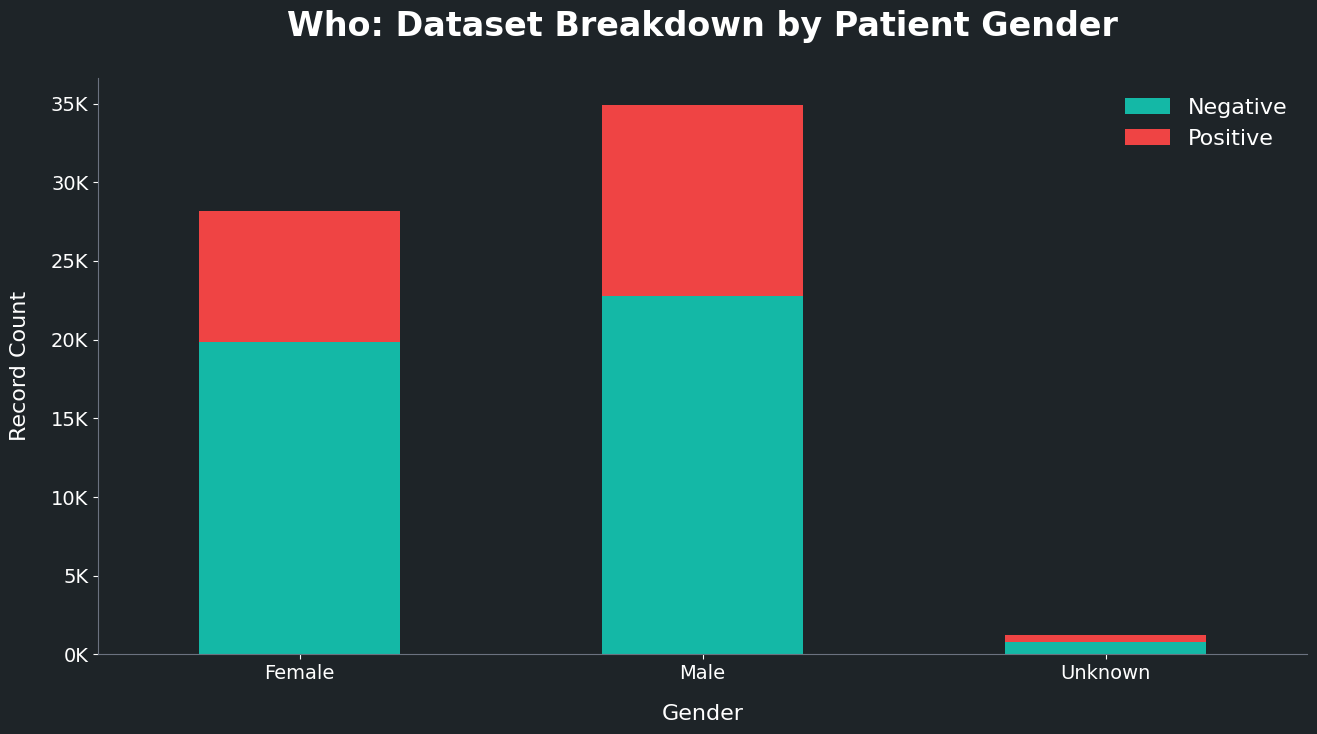

In [24]:
# Chart 2: Who - Records by Gender
fig, ax = plt.subplots(figsize=(13.33, 7.5))

g = by_cat["Gender"].unstack().fillna(0)[["Negative", "Positive"]]
g.plot.bar(stacked=True, ax=ax, color=[TEAL, RED], legend=False, width=0.5)

# Slide Formatting and Labels
ax.set_title("Who: Dataset Breakdown by Patient Gender", fontsize=24, fontweight="bold", pad=30, color="white")
ax.set_xlabel("Gender", fontsize=16, labelpad=15)
ax.set_ylabel("Record Count", fontsize=16, labelpad=15)
ax.tick_params(axis="both", labelsize=14)
ax.tick_params(axis="x", rotation=0)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v/1000:.0f}K"))

# Slide Legend
ax.legend(["Negative", "Positive"], loc="upper right", frameon=False, fontsize=16)

plt.tight_layout()
plt.show()

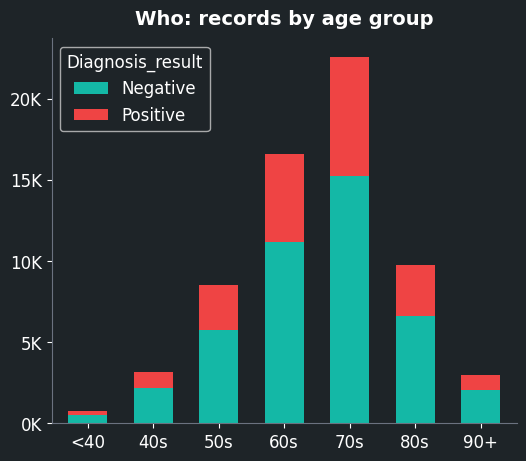

In [14]:
# Chart 3: Who - Records by Age Group
fig, ax = plt.subplots(figsize=(13.33, 7.5))

bands = pd.cut(a.index, bins=[0, 40, 50, 60, 70, 80, 90, 200], right=False,
               labels=["<40", "40s", "50s", "60s", "70s", "80s", "90+"])
ab = a.groupby(bands, observed=True).sum()[["Negative", "Positive"]]
ab.plot.bar(stacked=True, ax=ax, color=[TEAL, RED], legend=False, width=0.6)

# Slide Formatting and Labels
ax.set_title("Who: Distribution Across Patient Age Cohorts", fontsize=24, fontweight="bold", pad=30, color="white")
ax.set_xlabel("Age Group", fontsize=16, labelpad=15)
ax.set_ylabel("Record Count", fontsize=16, labelpad=15)
ax.tick_params(axis="both", labelsize=14)
ax.tick_params(axis="x", rotation=0)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v/1000:.0f}K"))

# Slide Legend
ax.legend(["Negative", "Positive"], loc="upper right", frameon=False, fontsize=16)

plt.tight_layout()
plt.show()

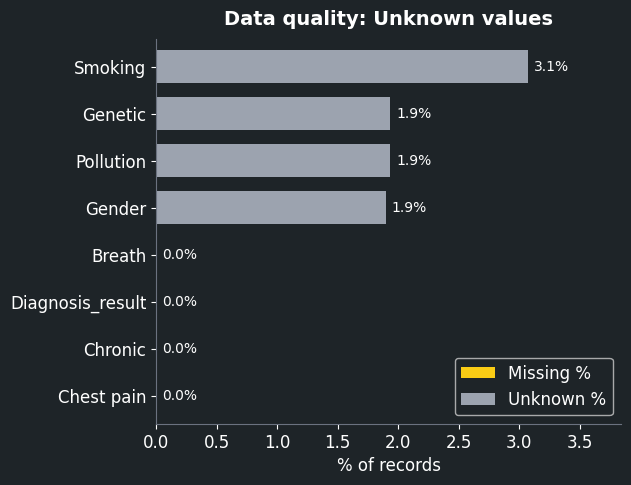

In [15]:
# Chart 4: Data Quality - Missing & Unknown Values
fig, ax = plt.subplots(figsize=(13.33, 7.5))

short = {"Smoking_status": "Smoking", "Shortness_of_breath": "Breath", "Genetic_risk": "Genetic",
         "Gender": "Gender", "Chronic_lung_disease": "Chronic", "Chest_pain": "Chest pain",
         "Air_pollution_exposure": "Pollution"}
unknown = pd.Series({c: by_cat[c].groupby(level=0).sum().get("Unknown", 0) for c in cat_cols})
dq = pd.DataFrame({"Missing %": nulls / rows * 100, "Unknown %": unknown / rows * 100}).fillna(0)
dq = dq.loc[(dq > 0).any(axis=1), (dq > 0).any(axis=0)]

if dq.empty:
    ax.text(0.5, 0.5, "No missing or Unknown values", ha="center", transform=ax.transAxes, fontsize=18)
    ax.axis("off")
else:
    dq = dq.loc[dq.sum(axis=1).sort_values().index]
    dq.index = [short.get(i, i) for i in dq.index]
    dq.plot.barh(stacked=True, ax=ax, legend=False, width=0.6,
                 color=[{"Missing %": GOLD, "Unknown %": GRAY}[c] for c in dq.columns])

    for i, v in enumerate(dq.sum(axis=1)):
        ax.text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=14, fontweight="bold", color="white")

    ax.set_xlim(0, dq.sum(axis=1).max() * 1.2)
    ax.set_xlabel("% of total records", fontsize=16, labelpad=15)
    ax.tick_params(axis="both", labelsize=14)

# Slide Title and Legend
ax.set_title("Data Integrity: Unknown Values & Quality Check", fontsize=24, fontweight="bold", pad=30, color="white")
ax.legend(["Missing %", "Unknown %"], loc="lower right", frameon=False, fontsize=16)

plt.tight_layout()
plt.show()

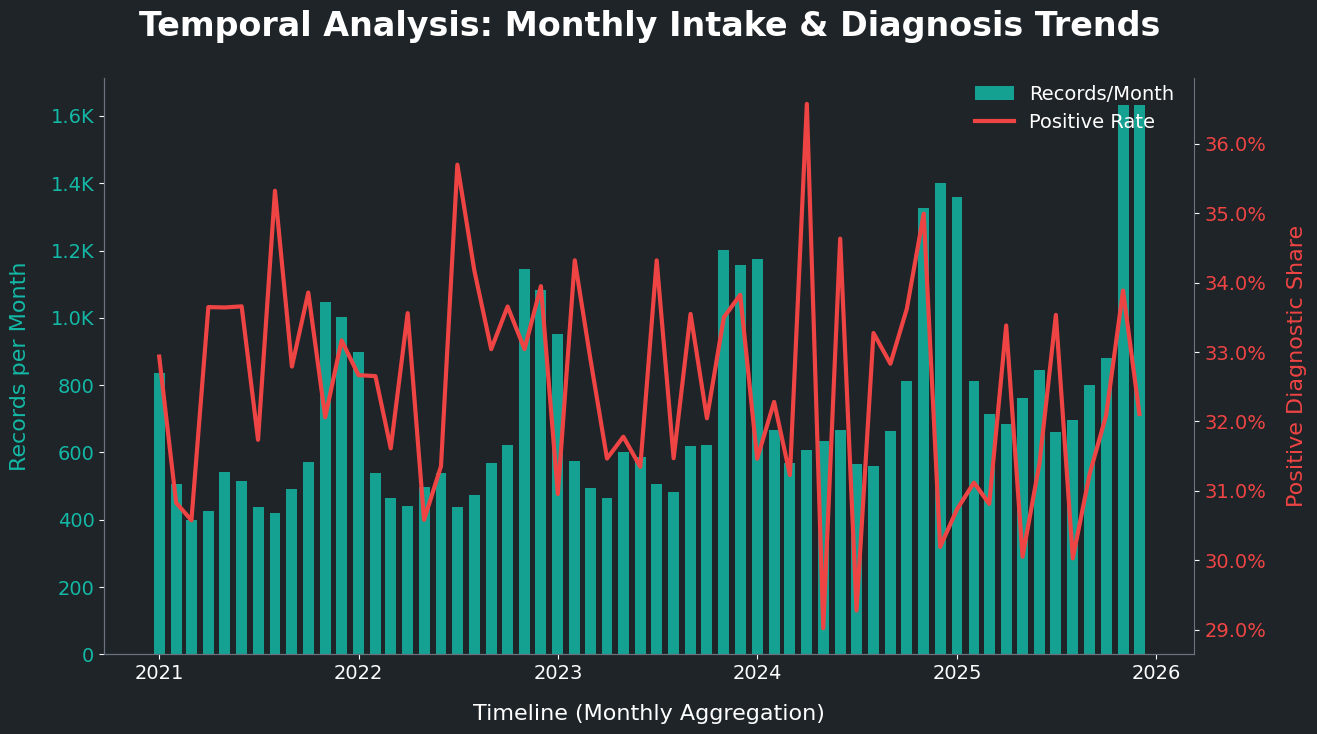

In [16]:
# Chart 5: When - Monthly Volume & Positive Rate
fig, ax = plt.subplots(figsize=(13.33, 7.5))

m = month.unstack().fillna(0)
m.index = m.index.to_timestamp()
m = m[(m.index.year >= START_YEAR) & (m.index.year <= END_YEAR)]
visits = m.sum(axis=1); rate = m["Positive"] / visits

# Monthly Volume
ax.bar(m.index, visits, width=20, color=TEAL, alpha=0.85, label="Records/Month")
ax.set_ylabel("Records per Month", fontsize=16, color=TEAL, labelpad=15)
ax.tick_params(axis="y", labelcolor=TEAL, labelsize=14)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v/1000:.1f}K" if v >= 1000 else f"{v:.0f}"))

# Dual Axis: Positive Rate
ax2 = ax.twinx()
ax2.spines["right"].set_visible(True)
ax2.plot(m.index, rate, color=RED, linewidth=3, label="Positive Rate")
ax2.set_ylabel("Positive Diagnostic Share", fontsize=16, color=RED, labelpad=15)
ax2.tick_params(axis="y", labelcolor=RED, labelsize=14)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

# Axis Formatting
ax.set_xlabel("Timeline (Monthly Aggregation)", fontsize=16, labelpad=15)
ax.tick_params(axis="x", labelsize=14)

# Title and Legends
ax.set_title("Temporal Analysis: Monthly Intake & Diagnosis Trends", fontsize=24, fontweight="bold", pad=30, color="white")
fig.legend(loc="upper right", frameon=False, fontsize=14, bbox_to_anchor=(0.9, 0.9))

plt.tight_layout()
plt.show()

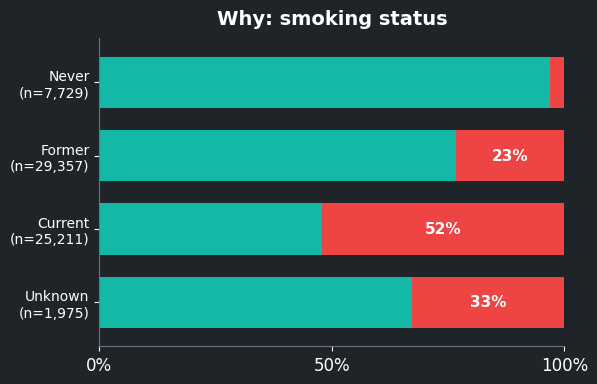

In [17]:
# Chart 6: Why - Smoking Status
fig, ax = plt.subplots(figsize=(13.33, 7.5))

stacked_pct(ax, "Smoking_status",
            ["Never", "Former", "Current", "Unknown"], "Risk Factors: Positive Share by Smoking Status")

# Scale Up Font Sizes for Slide Presentation
ax.set_title(ax.get_title(), fontsize=24, fontweight="bold", pad=30, color="white")
ax.tick_params(axis="both", labelsize=15)
ax.set_xlabel("Diagnosis Probability", fontsize=16, labelpad=15)

# Side Legend
fig.legend(handles=[Patch(color=TEAL, label="Negative"), Patch(color=RED, label="Positive")],
           loc="upper right", frameon=False, fontsize=16, bbox_to_anchor=(0.9, 0.9))

plt.tight_layout()
plt.show()

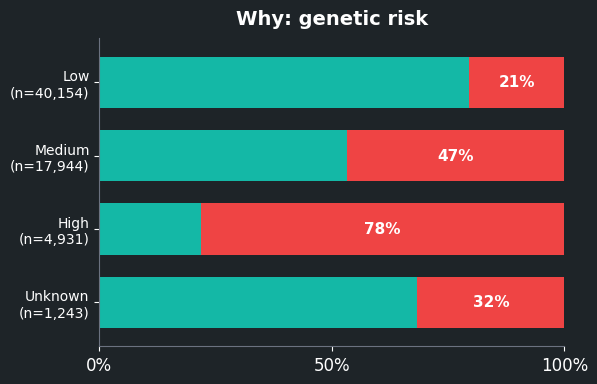

In [18]:
# Chart 7: Why - Genetic Risk
fig, ax = plt.subplots(figsize=(13.33, 7.5))

stacked_pct(ax, "Genetic_risk",
            ["Low", "Medium", "High", "Unknown"], "Risk Factors: Positive Share by Genetic Risk Level")

# Scale Up Font Sizes for Slide Presentation
ax.set_title(ax.get_title(), fontsize=24, fontweight="bold", pad=30, color="white")
ax.tick_params(axis="both", labelsize=15)
ax.set_xlabel("Diagnosis Probability", fontsize=16, labelpad=15)

# Slide Legend
fig.legend(handles=[Patch(color=TEAL, label="Negative"), Patch(color=RED, label="Positive")],
           loc="upper right", frameon=False, fontsize=16, bbox_to_anchor=(0.9, 0.9))

plt.tight_layout()
plt.show()

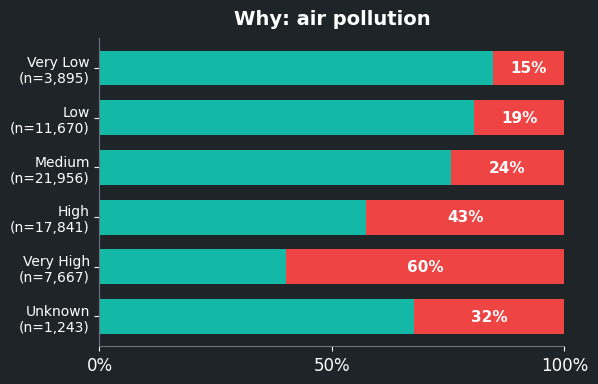

In [19]:
# Chart 8: Why - Air Pollution
fig, ax = plt.subplots(figsize=(13.33, 7.5))

stacked_pct(ax, "Air_pollution_exposure",
            ["Very Low", "Low", "Medium", "High", "Very High", "Unknown"], "Environmental Impact: Positive Share by Air Pollution Exposure")

# Scale Up Font Sizes for Slide Presentation
ax.set_title(ax.get_title(), fontsize=24, fontweight="bold", pad=30, color="white")
ax.tick_params(axis="both", labelsize=15)
ax.set_xlabel("Diagnosis Probability", fontsize=16, labelpad=15)

# Slide Legend
fig.legend(handles=[Patch(color=TEAL, label="Negative"), Patch(color=RED, label="Positive")],
           loc="upper right", frameon=False, fontsize=16, bbox_to_anchor=(0.9, 0.9))

plt.tight_layout()
plt.show()

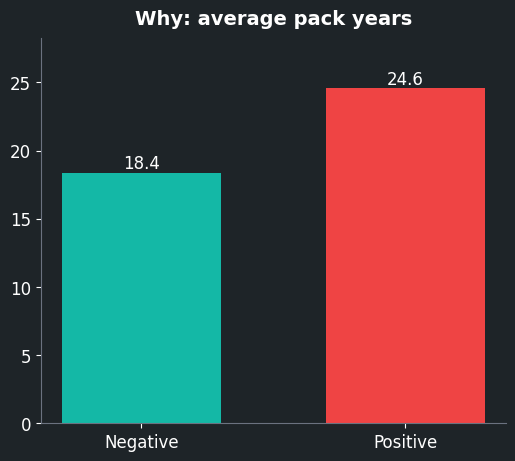

In [20]:
# Chart 9: Why - Average Pack Years
fig, ax = plt.subplots(figsize=(13.33, 7.5))

ax.bar(avg_pack.index, avg_pack.values, color=[TEAL, RED], width=0.45)
for i, v in enumerate(avg_pack.values):
    ax.text(i, v + 0.5, f"{v:.1f} yrs", ha="center", va="bottom", fontsize=18, fontweight="bold", color="white")

ax.set_ylim(0, avg_pack.max() * 1.2)
ax.set_title("Risk Factors: Average Tobacco Pack-Years by Outcome", fontsize=24, fontweight="bold", pad=30, color="white")
ax.set_ylabel("Average Pack-Years", fontsize=16, labelpad=15)
ax.tick_params(axis="both", labelsize=15)

plt.tight_layout()
plt.show()

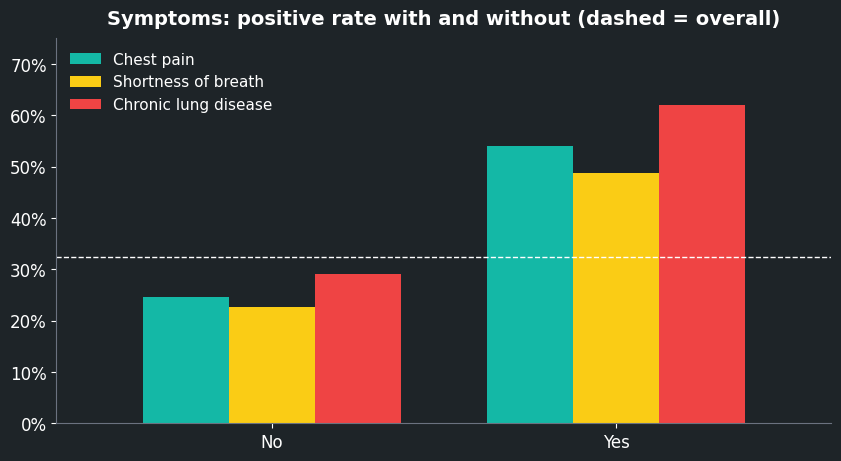

In [21]:
# Full Presentation-Ready Dashboard: 16:9 Landscape Layout optimized for PPT Morph/Zoom transitions
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch
import pandas as pd

# Reuse defined colors
TEAL, RED, GOLD, GRAY, BG = "#14B8A6", "#EF4444", "#FACC15", "#9CA3AF", "#1E2428"

# Configure global parameters for crisp slide rendering
plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "axes.edgecolor": "#6B7280", "text.color": "white", "axes.labelcolor": "white",
    "xtick.color": "white", "ytick.color": "white",
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 13})

fig = plt.figure(figsize=(24, 13.5))
gs = fig.add_gridspec(4, 4, height_ratios=[0.6, 3, 3, 3],
                      left=0.04, right=0.96, top=0.95, bottom=0.06, hspace=0.5, wspace=0.45)

# Slide Header Row
h = fig.add_subplot(gs[0, :]); h.axis("off")
h.text(0, 1.0, "Lung Cancer Story: Widescreen Clinical Dashboard",
       fontsize=28, fontweight="bold", va="top", transform=h.transAxes, color="white")
h.text(0, 0.1, f"{total:,.0f} patient records   |   {pos_rate:.1%} positive rate   |   average age {avg_age:.1f}",
       fontsize=16, color=TEAL, va="top", transform=h.transAxes, fontweight="bold")

# ---------- Row 1: big picture, who, data quality ----------
# 1. Big Picture Pie
ax1 = fig.add_subplot(gs[1, 0])
ax1.pie(diag[["Negative", "Positive"]], colors=[TEAL, RED], startangle=90, autopct="%1.1f%%",
       pctdistance=0.72, wedgeprops=dict(width=0.45, edgecolor=BG),
       textprops=dict(color="black", fontweight="bold", fontsize=12))
ax1.text(0, 0, f"{total:,.0f}\nrecords", ha="center", va="center", fontsize=13, fontweight="bold")
ax1.set_title("1. Big Picture Status", fontsize=15, fontweight="bold", pad=15)

# 2. Who: Gender
ax2 = fig.add_subplot(gs[1, 1])
g = by_cat["Gender"].unstack().fillna(0)[["Negative", "Positive"]]
g.plot.bar(stacked=True, ax=ax2, color=[TEAL, RED], legend=False, width=0.55)
ax2.set_title("2. Records by Gender", fontsize=15, fontweight="bold", pad=15)
ax2.set_xlabel(""); ax2.tick_params(axis="x", rotation=0)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v/1000:.0f}K"))

# 3. Who: Age Group
ax3 = fig.add_subplot(gs[1, 2])
bands = pd.cut(a.index, bins=[0, 40, 50, 60, 70, 80, 90, 200], right=False,
               labels=["<40", "40s", "50s", "60s", "70s", "80s", "90+"])
ab = a.groupby(bands, observed=True).sum()[["Negative", "Positive"]]
ab.plot.bar(stacked=True, ax=ax3, color=[TEAL, RED], legend=False, width=0.6)
ax3.set_title("3. Records by Age Group", fontsize=15, fontweight="bold", pad=15)
ax3.set_xlabel(""); ax3.tick_params(axis="x", rotation=0)
ax3.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v/1000:.0f}K"))

# 4. Data Quality
ax4 = fig.add_subplot(gs[1, 3])
short = {"Smoking_status": "Smoking", "Shortness_of_breath": "Breath", "Genetic_risk": "Genetic",
         "Gender": "Gender", "Chronic_lung_disease": "Chronic", "Chest_pain": "Chest pain",
         "Air_pollution_exposure": "Pollution"}
unknown = pd.Series({c: by_cat[c].groupby(level=0).sum().get("Unknown", 0) for c in cat_cols})
dq = pd.DataFrame("Unknown %", unknown / rows * 100).fillna(0)
dq = dq.loc[dq.sum(axis=1).sort_values().index]
dq.index = [short.get(i, i) for i in dq.index]
dq.plot.barh(ax=ax4, legend=False, width=0.6, color=GRAY)
for i, v in enumerate(dq["Unknown %"]):
    ax4.text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=11, fontweight="bold")
ax4.set_xlim(0, dq["Unknown %"].max() * 1.25)
ax4.set_title("4. Data Quality Profile", fontsize=15, fontweight="bold", pad=15)
ax4.set_xlabel("% Unknown"); ax4.set_ylabel("")

# ---------- Row 2: when, smoking, genetic risk ----------
# 5. Timeline
ax5 = fig.add_subplot(gs[2, 0:2])
m = month.unstack().fillna(0)
m.index = m.index.to_timestamp()
m = m[(m.index.year >= START_YEAR) & (m.index.year <= END_YEAR)]
visits = m.sum(axis=1); rate = m["Positive"] / visits
ax5.bar(m.index, visits, width=22, color=TEAL, alpha=0.9)
ax5.set_ylabel("Volume / Month", color=TEAL, fontsize=12)
ax5.tick_params(axis="y", labelcolor=TEAL)
ax5.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v/1000:.1f}K"))

ax5_twin = ax5.twinx(); ax5_twin.spines["right"].set_visible(True)
ax5_twin.plot(m.index, rate, color=RED, linewidth=2.5)
ax5_twin.tick_params(axis="y", labelcolor=RED)
ax5_twin.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))
ax5_twin.set_ylabel("Positive %", color=RED, fontsize=12)
ax5.set_title("5. Temporal Influx & Positive Diagnostics Rate", fontsize=15, fontweight="bold", pad=15)

# Helper function to plot in subgrid to match widescreen spacing requirements
def slide_stacked_pct(ax, col, order, title_text):
    t = by_cat[col].unstack().fillna(0)[["Negative", "Positive"]]
    order = [o for o in order if o in t.index] + [i for i in t.index if i not in order]
    t = t.reindex(order)
    pct = t.div(t.sum(axis=1), axis=0)
    pct.plot.barh(stacked=True, ax=ax, color=[TEAL, RED], legend=False, width=0.65)
    ax.set_yticks(range(len(t)))
    ax.set_yticklabels([f"{i}\n(n={n:,.0f})" for i, n in zip(t.index, t.sum(axis=1))], fontsize=10)
    for i, p in enumerate(pct["Positive"]):
        if p > 0.08:
            ax.text(1 - p / 2, i, f"{p:.0%}", ha="center", va="center", color="white", fontweight="bold", fontsize=11)
    ax.invert_yaxis(); ax.set_ylabel(""); ax.set_xlim(0, 1)
    ax.set_xticks([0, .5, 1]); ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(title_text, fontsize=15, fontweight="bold", pad=15)

# 6. Smoking Status
ax6 = fig.add_subplot(gs[2, 2])
slide_stacked_pct(ax6, "Smoking_status", ["Never", "Former", "Current", "Unknown"], "6. Impact of Smoking Status")

# 7. Genetic Risk
ax7 = fig.add_subplot(gs[2, 3])
slide_stacked_pct(ax7, "Genetic_risk", ["Low", "Medium", "High", "Unknown"], "7. Role of Genetic Risk")

# ---------- Row 3: air pollution, pack years, symptoms ----------
# 8. Air Pollution
ax8 = fig.add_subplot(gs[3, 0])
slide_stacked_pct(ax8, "Air_pollution_exposure", ["Very Low", "Low", "Medium", "High", "Very High", "Unknown"], "8. Air Pollution Impact")

# 9. Pack Years
ax9 = fig.add_subplot(gs[3, 1])
ax9.bar(avg_pack.index, avg_pack.values, color=[TEAL, RED], width=0.5)
for i, v in enumerate(avg_pack.values):
    ax9.text(i, v + 0.6, f"{v:.1f} yrs", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax9.set_ylim(0, avg_pack.max() * 1.25)
ax9.set_ylabel("Avg Tobacco Pack-Years")
ax9.set_title("9. Tobacco Load by Cohort", fontsize=15, fontweight="bold", pad=15)

# 10. Symptoms Chart
ax10 = fig.add_subplot(gs[3, 2:4])
rates = {}
for c in ["Chest_pain", "Shortness_of_breath", "Chronic_lung_disease"]:
    t = by_cat[c].unstack().fillna(0)
    rates[c.replace("_", " ")] = t["Positive"] / t.sum(axis=1)
pd.DataFrame(rates).plot.bar(ax=ax10, color=[TEAL, GOLD, RED], width=0.65)
ax10.axhline(pos_rate, color="white", linestyle="--", linewidth=1.2)
ax10.set_ylim(0, 0.85)
ax10.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax10.tick_params(axis="x", rotation=0)
ax10.set_title("10. Diagnostic Probability by Key Symptoms", fontsize=15, fontweight="bold", pad=15)
ax10.legend(frameon=False, loc="upper left", fontsize=10)

# Main Figure legend & Footnote
fig.legend(handles=[Patch(color=TEAL, label="Negative"), Patch(color=RED, label="Positive")],
           loc="upper right", frameon=False, fontsize=15, bbox_to_anchor=(0.96, 0.95))

plt.show()